# <center> **Práctica No.2** </center>
# <center> **Análisis de Fraude en Tarjetas de Crédito** </center>

#### Nombre: Karina R. Romero Flores

Se descargo el dataset del link: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Instalando matplotlib

In [1]:
!pip install scikit-learn matplotlib seaborn


Defaulting to user installation because normal site-packages is not writeable


In [2]:
#Cargando el dataset
import pandas as pd

df = pd.read_csv(r"C:/Users/karen/Downloads/PRACTICA_Nro1/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Análisis Exploratorio de Datos

In [3]:
import pandas as pd

# Cargar el dataset
df = pd.read_csv('creditcard.csv')

# Información general
print("=== Información del Dataset ===")
print(df.info())

# Estadísticas descriptivas
print("\n=== Estadísticas Descriptivas ===")
print(df.describe())

# Verificación de valores nulos
print("\n=== Valores Nulos por Columna ===")
print(df.isnull().sum())

# Verificación de duplicados
print("\n=== Número de Registros Duplicados ===")
print(df.duplicated().sum())

# Distribución de clases
print("\n=== Distribución de Clases ===")
print(df['Class'].value_counts(normalize=True) * 100)


=== Información del Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 n

### Ver cuántos duplicados hay

In [4]:
duplicados = df.duplicated().sum()
print(f"Número de registros duplicados: {duplicados}")


Número de registros duplicados: 1081


### Eliminar duplicados

In [6]:
df_limpio = df.drop_duplicates()


### Verificar que se eliminaron

In [7]:
print(f"Número de registros después de eliminar duplicados: {df_limpio.shape[0]}")


Número de registros después de eliminar duplicados: 283726


In [8]:
# Verificar duplicados
print("Duplicados antes:", df.duplicated().sum())

# Eliminar duplicados
df = df.drop_duplicates()

# Confirmar que se eliminaron
print("Duplicados después:", df.duplicated().sum())


Duplicados antes: 1081
Duplicados después: 0


Instalando scikit-learn matplotlib seaborn

In [9]:
!pip install scikit-learn matplotlib seaborn


Defaulting to user installation because normal site-packages is not writeable


### Árbol de Decisión

In [10]:
%matplotlib inline


=== Reporte de Clasificación - Árbol de Decisión ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.84      0.66      0.74        95

    accuracy                           1.00     56746
   macro avg       0.92      0.83      0.87     56746
weighted avg       1.00      1.00      1.00     56746



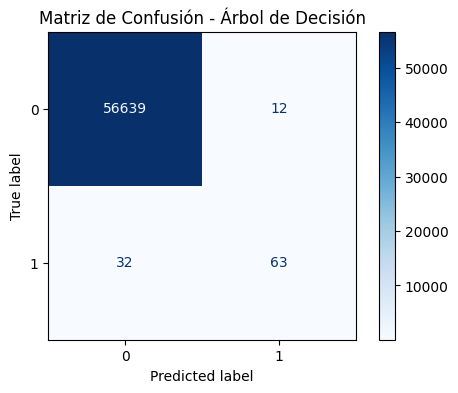

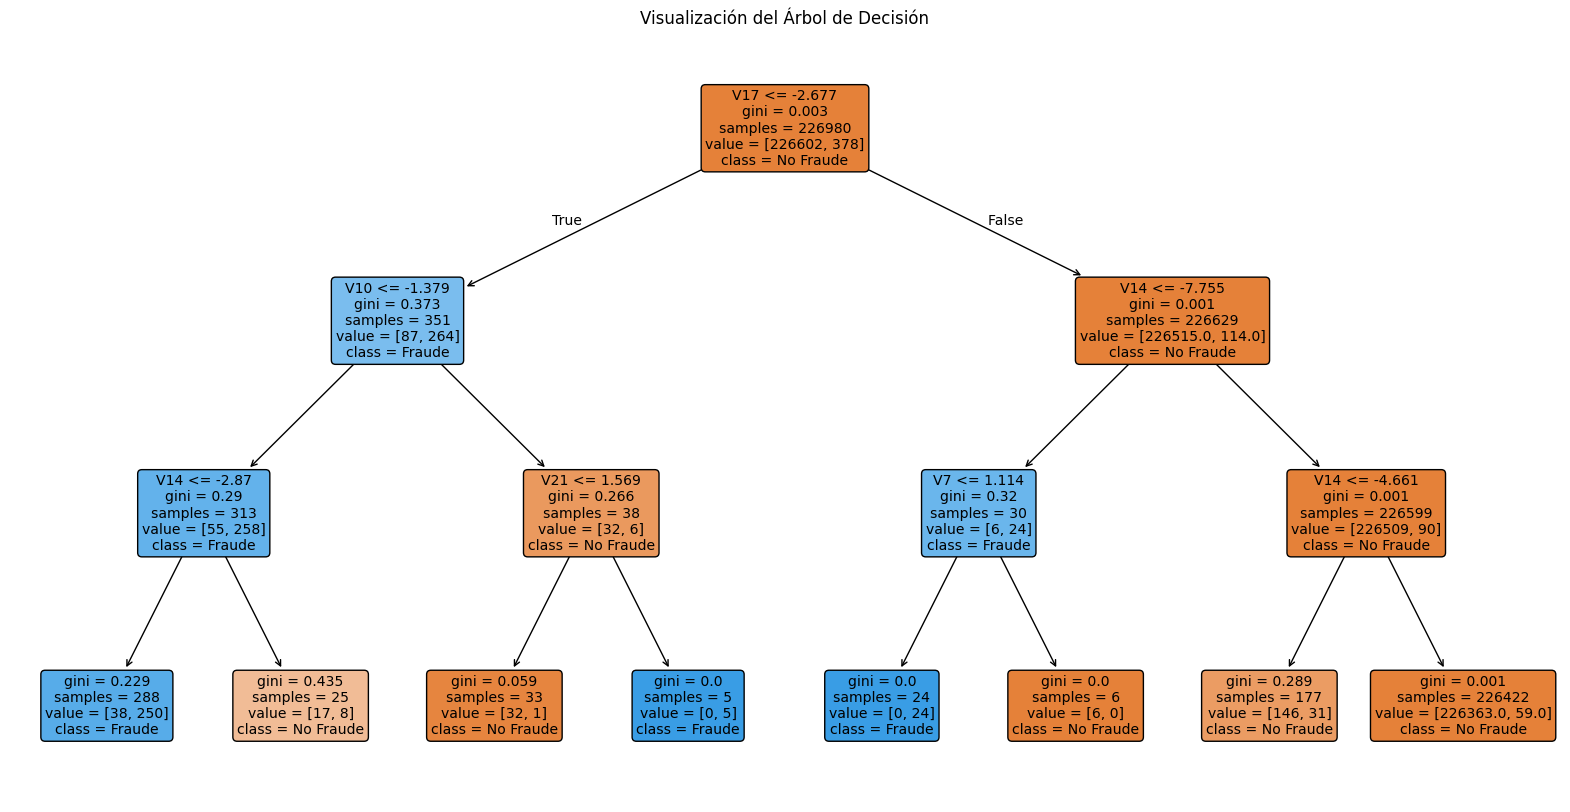

In [11]:
# Importar librerías necesarias
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Separar variables predictoras (X) y objetivo (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Dividir el dataset en entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Crear y entrenar el modelo de Árbol de Decisión
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)  # max_depth para visualización
dt_model.fit(X_train, y_train)

# Realizar predicciones
y_pred = dt_model.predict(X_test)

# Reporte de clasificación
print("=== Reporte de Clasificación - Árbol de Decisión ===")
print(classification_report(y_test, y_pred, zero_division=0))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.grid(False)
plt.show()

# Gráfico del Árbol de Decisión
plt.figure(figsize=(20, 10))
plot_tree(dt_model, filled=True, feature_names=X.columns, class_names=["No Fraude", "Fraude"], rounded=True)
plt.title("Visualización del Árbol de Decisión")
plt.show()


### Naïve Bayes

=== Reporte de Clasificación - Naïve Bayes ===
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56651
           1       0.14      0.64      0.23        95

    accuracy                           0.99     56746
   macro avg       0.57      0.82      0.61     56746
weighted avg       1.00      0.99      1.00     56746



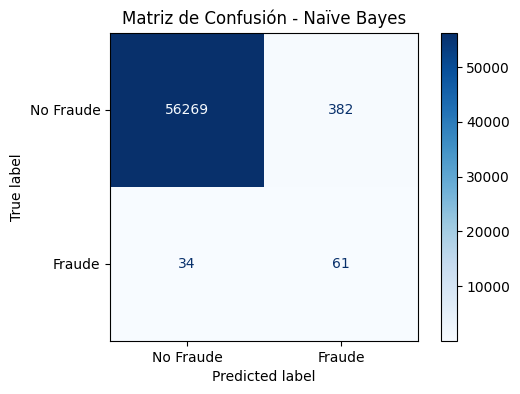

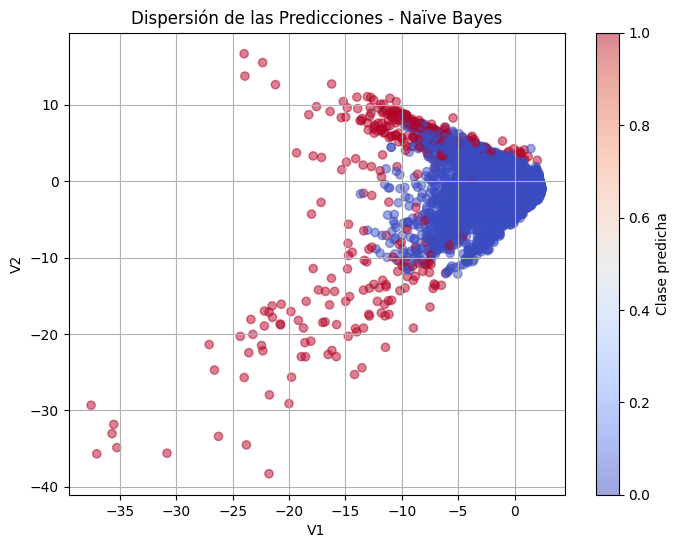

In [12]:
# Activar visualización de gráficos
%matplotlib inline

# Importar librerías necesarias
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Entrenar modelo de Naïve Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predicciones
y_pred_nb = nb_model.predict(X_test)

# Reporte
print("=== Reporte de Clasificación - Naïve Bayes ===")
print(classification_report(y_test, y_pred_nb, zero_division=0))

# Matriz de Confusión
cm_nb = confusion_matrix(y_test, y_pred_nb)
fig, ax = plt.subplots(figsize=(6, 4))
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=["No Fraude", "Fraude"])
disp_nb.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Matriz de Confusión - Naïve Bayes')
plt.grid(False)
plt.show()

# === Gráfico de Dispersión ===
# Usamos las dos primeras columnas para facilitar visualización
plt.figure(figsize=(8, 6))
plt.scatter(X_test['V1'], X_test['V2'], c=y_pred_nb, cmap='coolwarm', alpha=0.5)
plt.xlabel('V1')
plt.ylabel('V2')
plt.title('Dispersión de las Predicciones - Naïve Bayes')
plt.colorbar(label='Clase predicha')
plt.grid(True)
plt.show()


### Random Forest

In [13]:
!pip install pandas numpy matplotlib seaborn scikit-learn


Defaulting to user installation because normal site-packages is not writeable


In [13]:
!pip install scikit-learn matplotlib seaborn pandas --quiet

== Reporte de Clasificación ==
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



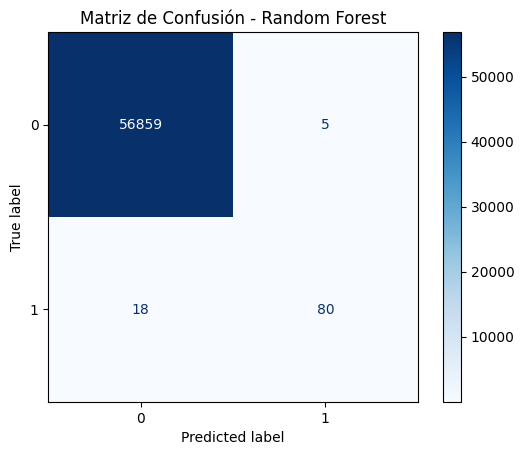

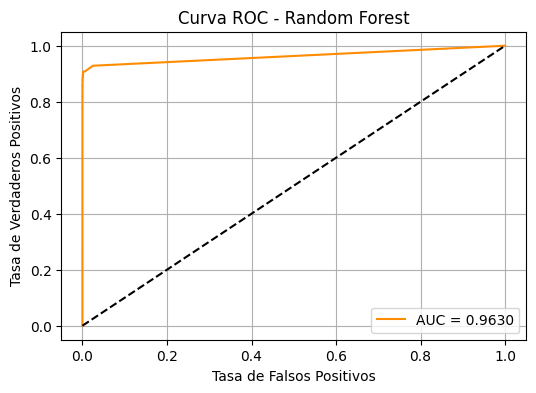

C:\Users\karen\AppData\Local\Temp\ipykernel_22624\444301723.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')


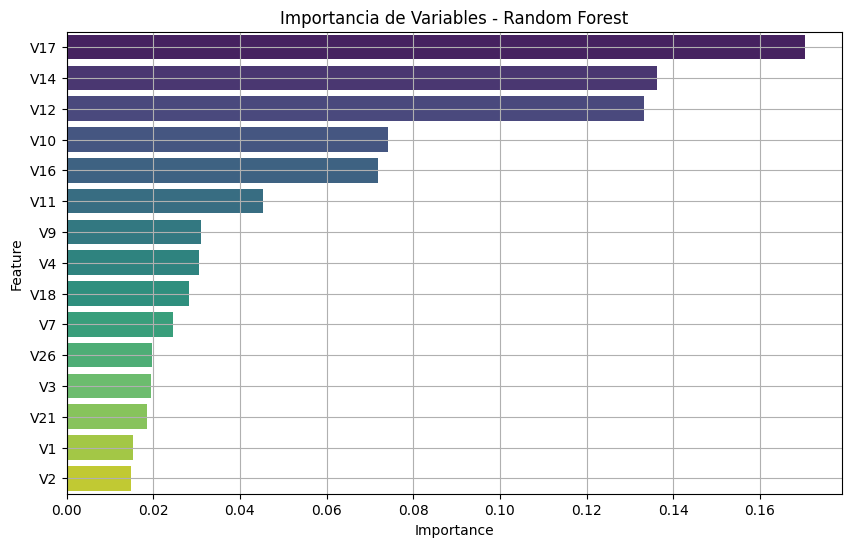

In [23]:
# Activar gráficos en línea
%matplotlib inline

# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

# Leer el archivo CSV
df = pd.read_csv(r"C:/Users/karen/Downloads/PRACTICA_Nro1/creditcard.csv")

# Separar variables predictoras y objetivo
X = df.drop('Class', axis=1)
y = df['Class']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Entrenar el modelo Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Reporte de clasificación
print("== Reporte de Clasificación ==")
print(classification_report(y_test, y_pred, zero_division=0))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión - Random Forest")
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", color="darkorange")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curva ROC - Random Forest")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Importancia de variables
importances = model.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title("Importancia de Variables - Random Forest")
plt.grid(True)
plt.show()


### Comparación de Rendimiento entre Árbol de Decisión y Random Forest

In [24]:
!pip install pandas numpy matplotlib seaborn scikit-learn


Defaulting to user installation because normal site-packages is not writeable


In [25]:
# Importar librerías
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Cargar datos
df = pd.read_csv(r"C:/Users/karen/Downloads/PRACTICA_Nro1/creditcard.csv")

# Variables predictoras y objetivo
X = df.drop('Class', axis=1)
y = df['Class']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# === Modelo Naïve Bayes ===
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
print("=== Clasificación - Naïve Bayes ===")
print(classification_report(y_test, y_pred_nb, zero_division=0))

# === Modelo Árbol de Decisión ===
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("=== Clasificación - Árbol de Decisión ===")
print(classification_report(y_test, y_pred_dt, zero_division=0))

# === Validación cruzada (10-fold) ===
from sklearn.model_selection import cross_val_score

cv_nb = cross_val_score(nb_model, X, y, cv=10, scoring='accuracy')
cv_dt = cross_val_score(dt_model, X, y, cv=10, scoring='accuracy')

# Mostrar resultados de validación cruzada
print("=== Validación Cruzada ===")
print(f"Naïve Bayes - Accuracy promedio: {cv_nb.mean():.4f} ± {cv_nb.std():.4f}")
print(f"Árbol de Decisión - Accuracy promedio: {cv_dt.mean():.4f} ± {cv_dt.std():.4f}")


=== Clasificación - Naïve Bayes ===
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.14      0.66      0.23        98

    accuracy                           0.99     56962
   macro avg       0.57      0.83      0.61     56962
weighted avg       1.00      0.99      0.99     56962

=== Clasificación - Árbol de Decisión ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.75      0.74      0.75        98

    accuracy                           1.00     56962
   macro avg       0.88      0.87      0.87     56962
weighted avg       1.00      1.00      1.00     56962

=== Validación Cruzada ===
Naïve Bayes - Accuracy promedio: 0.9926 ± 0.0012
Árbol de Decisión - Accuracy promedio: 0.9011 ± 0.2928


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Opcional: silenciar warnings
import warnings
warnings.filterwarnings("ignore")


In [ ]:
# Cargar el dataset (ajusta la ruta si es necesario)
df = pd.read_csv("creditcard.csv")
#df = pd.read_csv('creditcard.csv')
# Definir X e y
X = df.drop("Class", axis=1)
y = df["Class"]


In [ ]:
# Modelos a comparar
modelos = {
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Métricas para evaluar
metricas = ['accuracy', 'precision', 'recall', 'f1']

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [ ]:
# Evaluación cruzada de cada modelo y métrica
resultados = []

for nombre_modelo, modelo in modelos.items():
    print(f"\n=== {nombre_modelo} ===")
    for metrica in metricas:
        scores = cross_val_score(modelo, X, y, cv=cv, scoring=metrica, n_jobs=-1)
        media = np.mean(scores)
        desviacion = np.std(scores)
        print(f"{metrica.capitalize():<10}: {media:.4f} (+/- {desviacion:.4f})")
        resultados.append([nombre_modelo, metrica, media, desviacion])


In [ ]:
# Convertir resultados a DataFrame y mostrar como tabla
df_resultados = pd.DataFrame(resultados, columns=['Modelo', 'Métrica', 'Media', 'Desviación'])
df_pivot = df_resultados.pivot(index='Métrica', columns='Modelo', values='Media').round(4)
display(df_pivot)


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Configurar validación cruzada de 5 pliegues estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Definir los modelos
modelos = {
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Métricas a evaluar
metricas = ['accuracy', 'precision', 'recall', 'f1']

# Evaluar cada modelo con cada métrica
for nombre_modelo, modelo in modelos.items():
    print(f"\n=== Evaluación de {nombre_modelo} ===")
    for metrica in metricas:
        scores = cross_val_score(modelo, X, y, cv=cv, scoring=metrica, n_jobs=-1)
        print(f"{metrica.capitalize():<10}: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")


Evaluación con Validación Cruzada (K-Fold)

In [27]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
import numpy as np

# Crear una validación cruzada estratificada de 5 pliegues
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Diccionario de modelos
modelos = {
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "Naïve Bayes": GaussianNB(),
    #"Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Evaluación
for nombre, modelo in modelos.items():
    print(f"=== Validación Cruzada - {nombre} ===")
    scores = cross_val_score(modelo, X, y, cv=cv, scoring='f1', n_jobs=-1)
    print(f"F1-score promedio: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})\n")


=== Validación Cruzada - Árbol de Decisión ===
F1-score promedio: 0.7581 (+/- 0.0224)

=== Validación Cruzada - Naïve Bayes ===
F1-score promedio: 0.2405 (+/- 0.0176)

